In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

## 1. Data (perpating and loading)

In [55]:
weight = 0.7
bias = 0.3

start = 0 
end = 1
step = 0.01
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280],
         [0.3350],
         [0.3420],
         [0.3490],
         [0.3560],
         [0.3630]]))

In [56]:
len(X),len(y)

(100, 100)

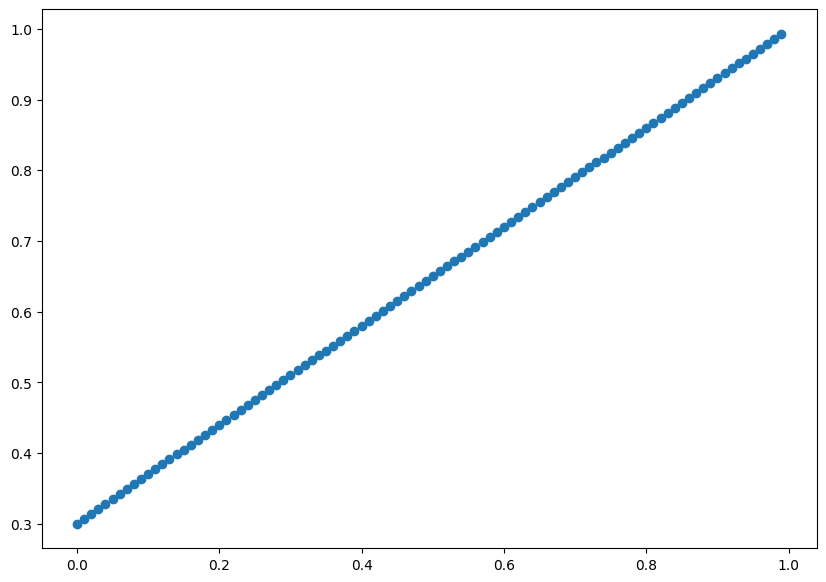

In [57]:
plt.figure(figsize=(10,7))
plt.scatter(X,y)
plt.show()

In [58]:
# X += 0.1*torch.randn_like(X)
y += 0.1*torch.randn_like(y)

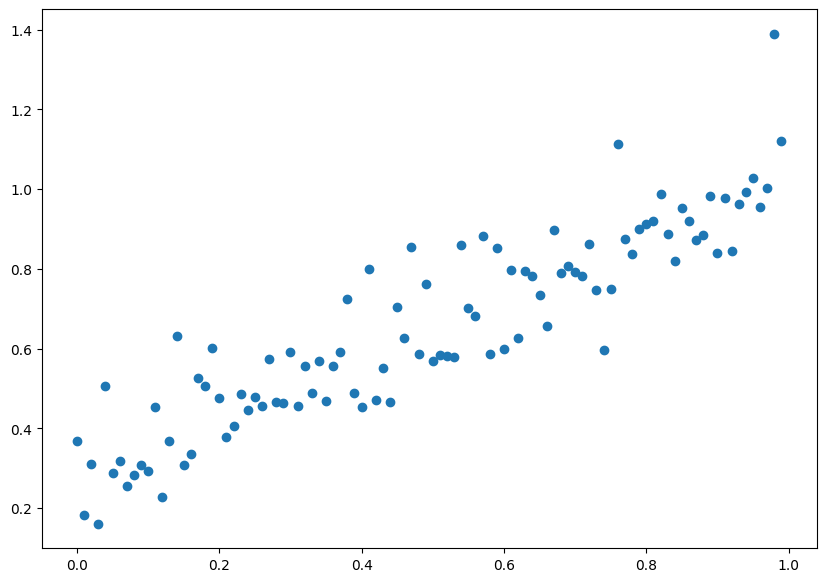

In [59]:
plt.figure(figsize=(10,7))
plt.scatter(X,y)
plt.show()

### Splitting data to train/test

In [60]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(80, 80, 20, 20)

In [61]:
def plot_prediction(X_train=X_train, 
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    prediction=None):

    plt.figure(figsize=(10,7))
    plt.scatter(X_train,y_train, label="Train data")
    plt.scatter(X_test,y_test, label="Test data")
    if prediction is not None :
        plt.scatter(X_test,prediction, label="Prediction")
    plt.show()

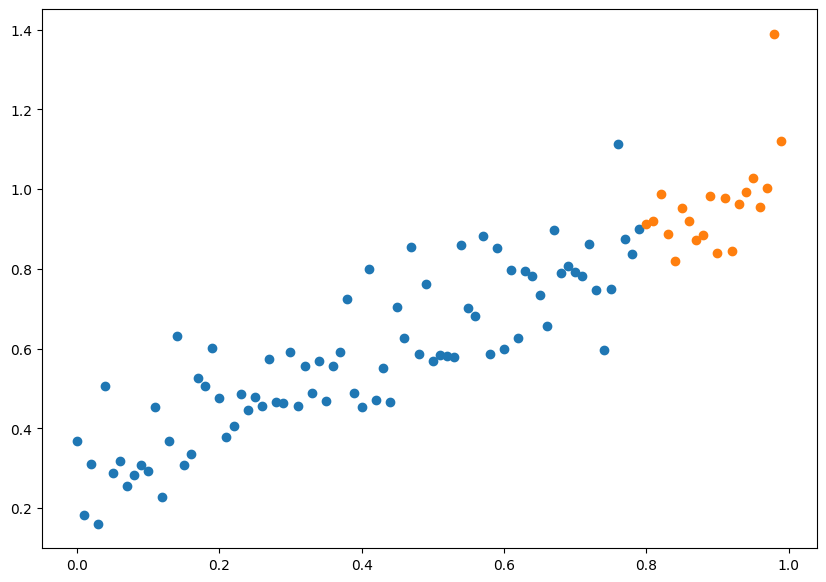

In [62]:
plot_prediction()

## 2. Build model

In [63]:
# Create linear regression model

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                            requires_grad=True, # Default is True
                            dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                            dtype=torch.float))
                            
    # Forward method for computation in the model
    def forward(self, x:torch.Tensor):
        return self.weights* x + self.bias
    

### Checking the content of PyTorch model

In [64]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

# Check out the parameter
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [65]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Make first prediction

In [72]:
with torch.inference_mode():
    y_pred = model_0(X_test)

#### The same as torch.inference_mode()
# with torch.no_grad():
#     y_pred = model_0(X_test)

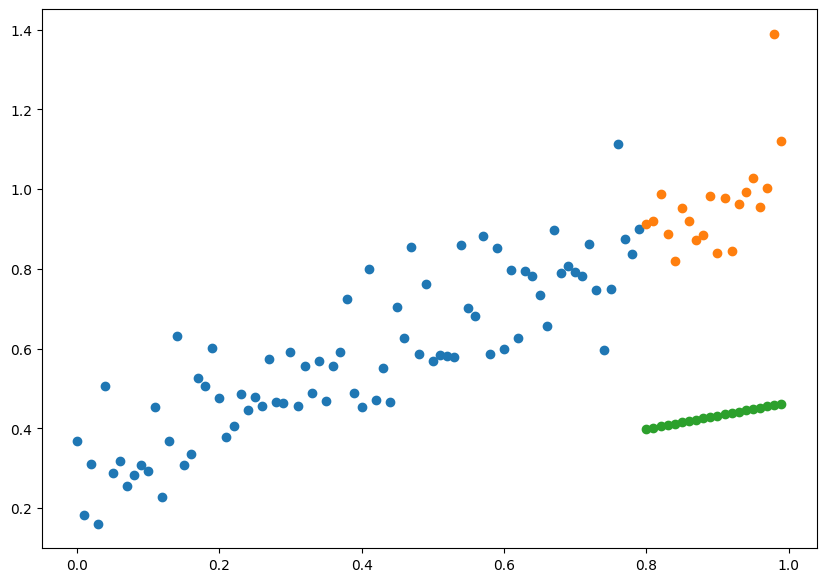

In [73]:
plot_prediction(prediction=y_pred)

## 3. Train model